 Dataset chargé : 149,434 lignes × 45 colonnes
 Distribution des classes :

             Nombre de flows  Pourcentage (%)
label                                        
Scanning               50135            33.55
Reco                   50135            33.55
DDoS                   14292             9.56
DoS                    14121             9.45
Normal                 13444             9.00
Bruteforce              5103             3.41
MITM                    1164             0.78
Reply                    792             0.53
FakeLanding              200             0.13
Evil                      48             0.03

Total : 149,434 flows — 10 classes


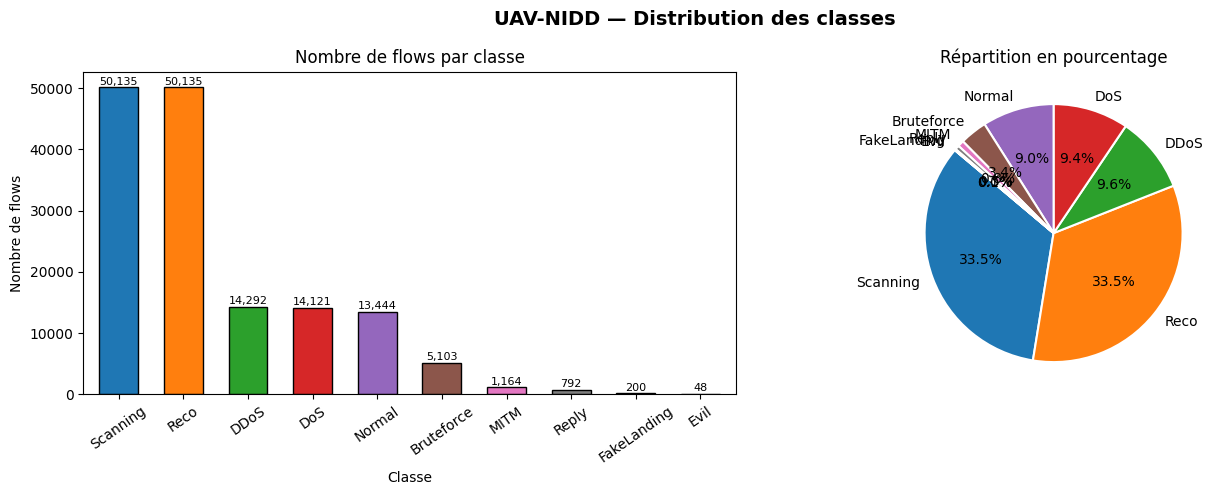

 Valeurs manquantes :

 Aucune valeur manquante détectée
 44 features numériques : ['flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'pkt_size_avg', 'fwd_seg_size_avg', 'subflow_fwd_pkts', 'subflow_fwd_byts']


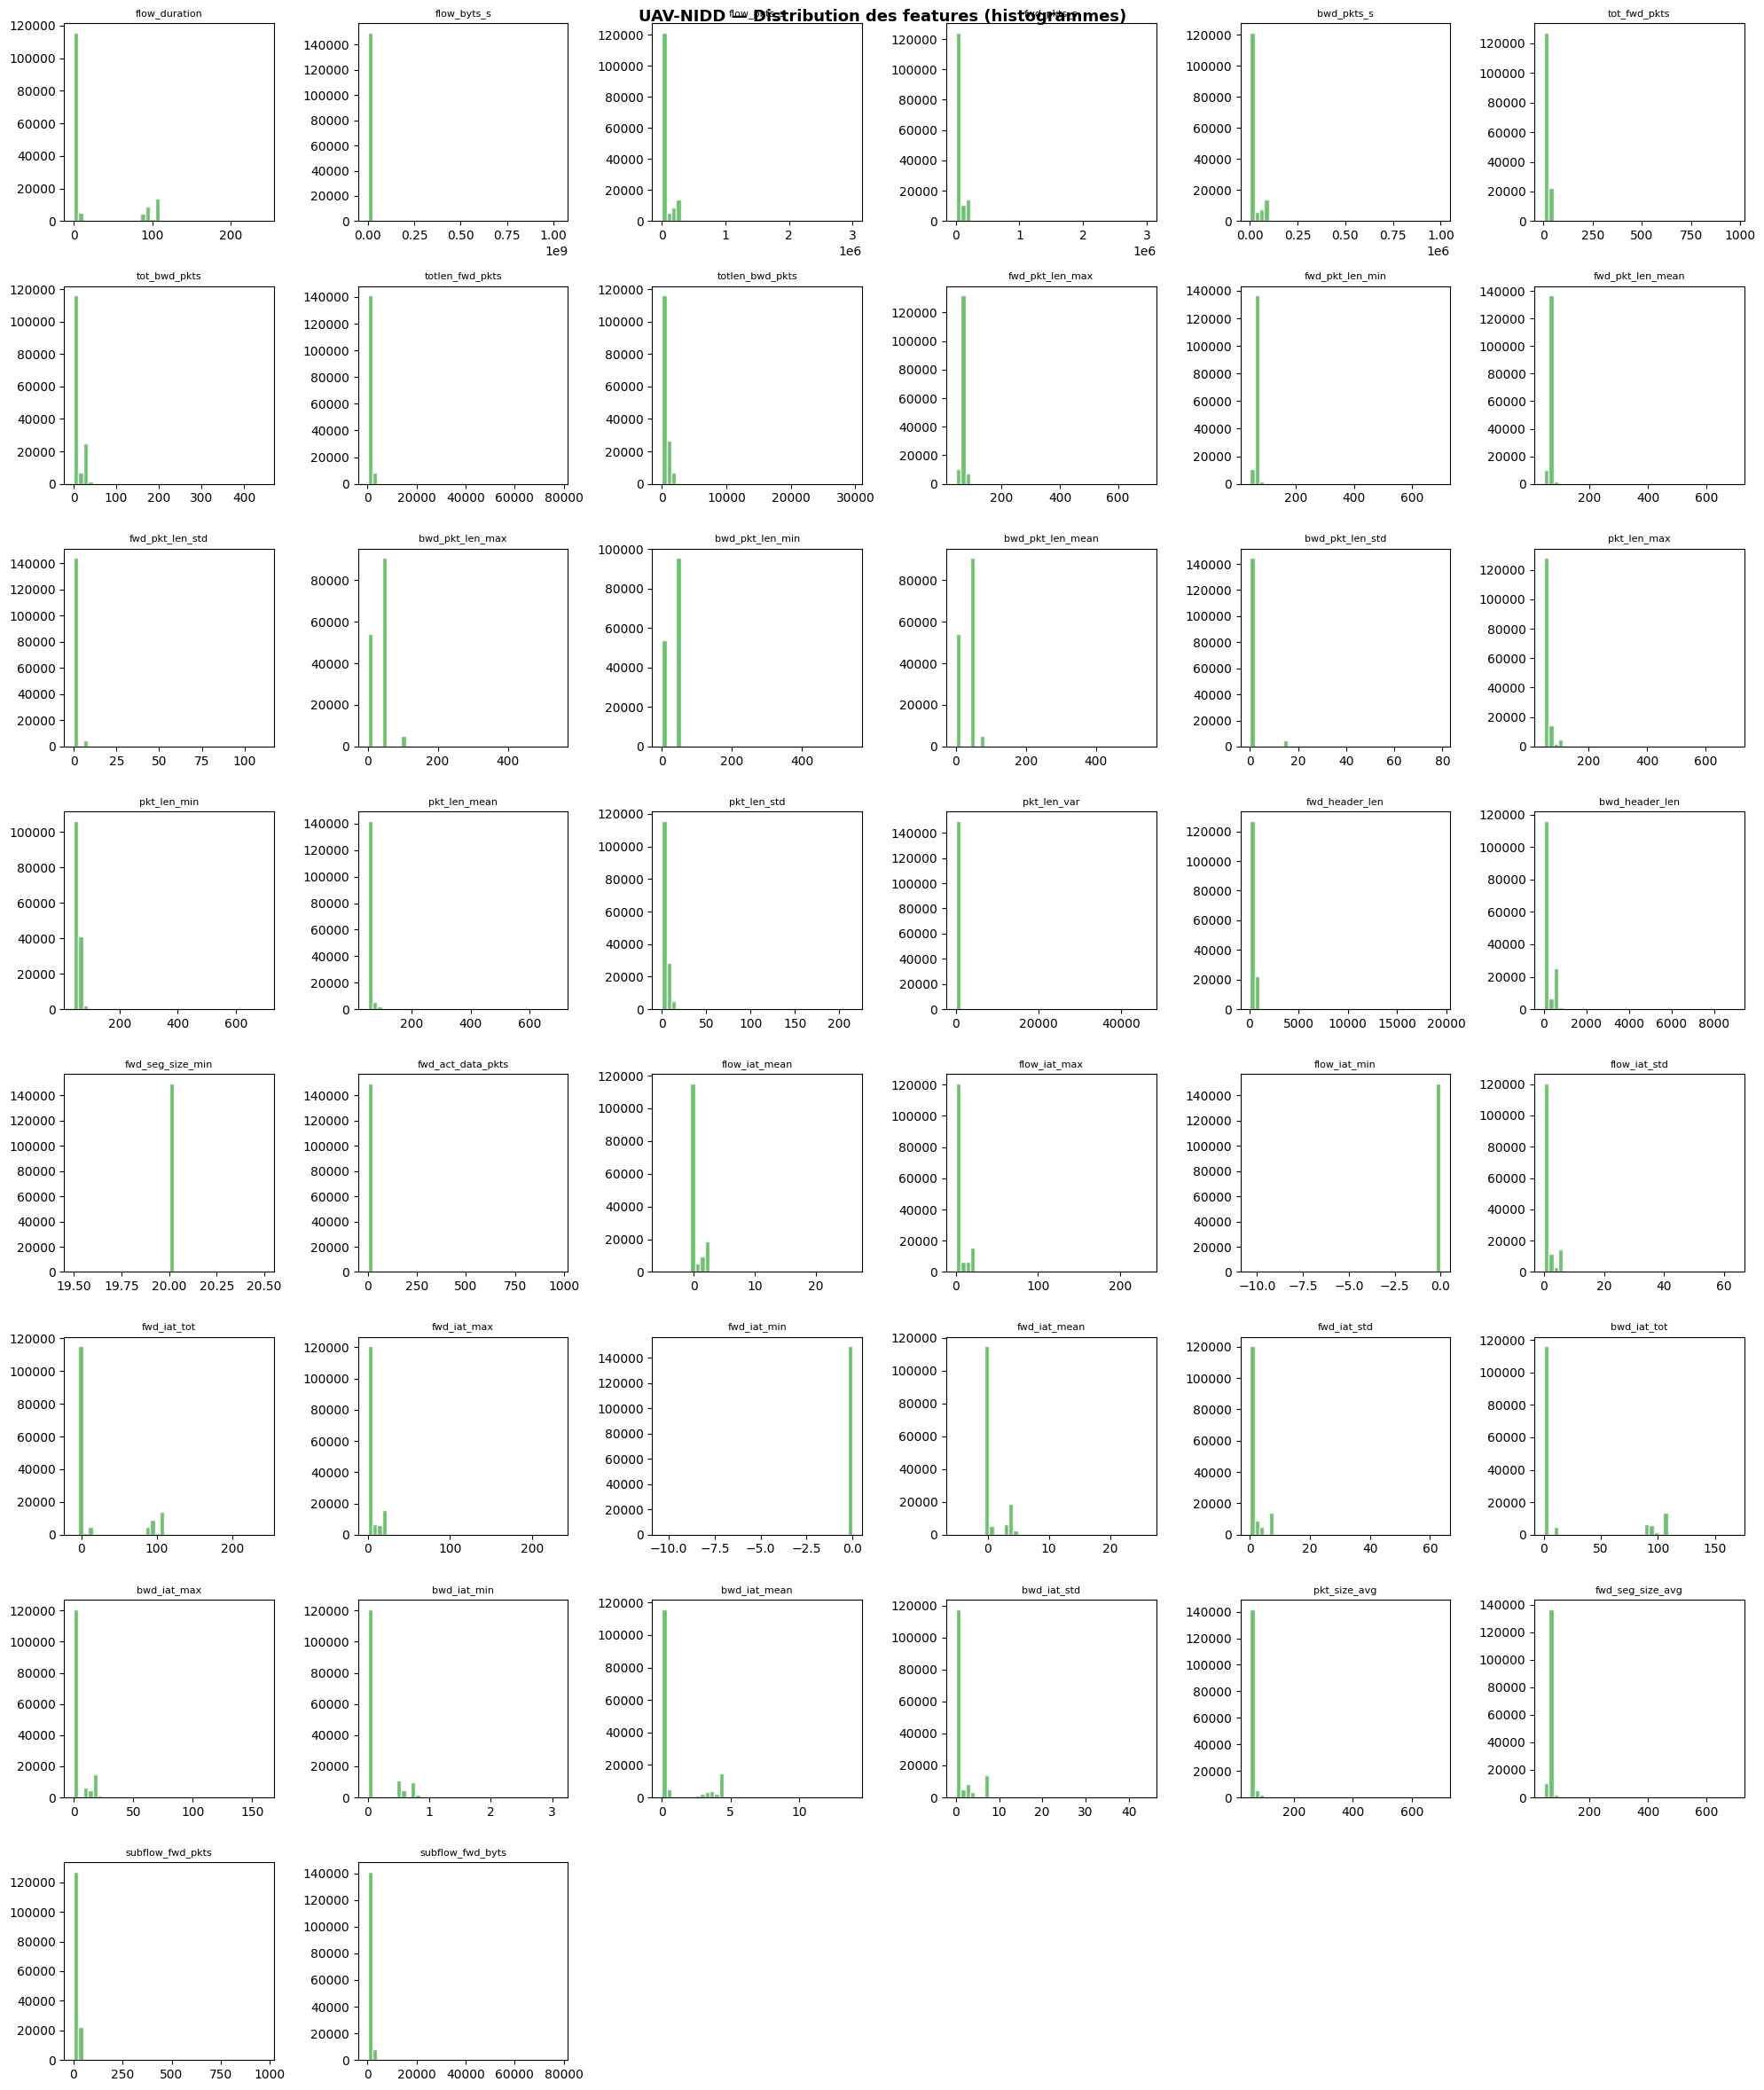

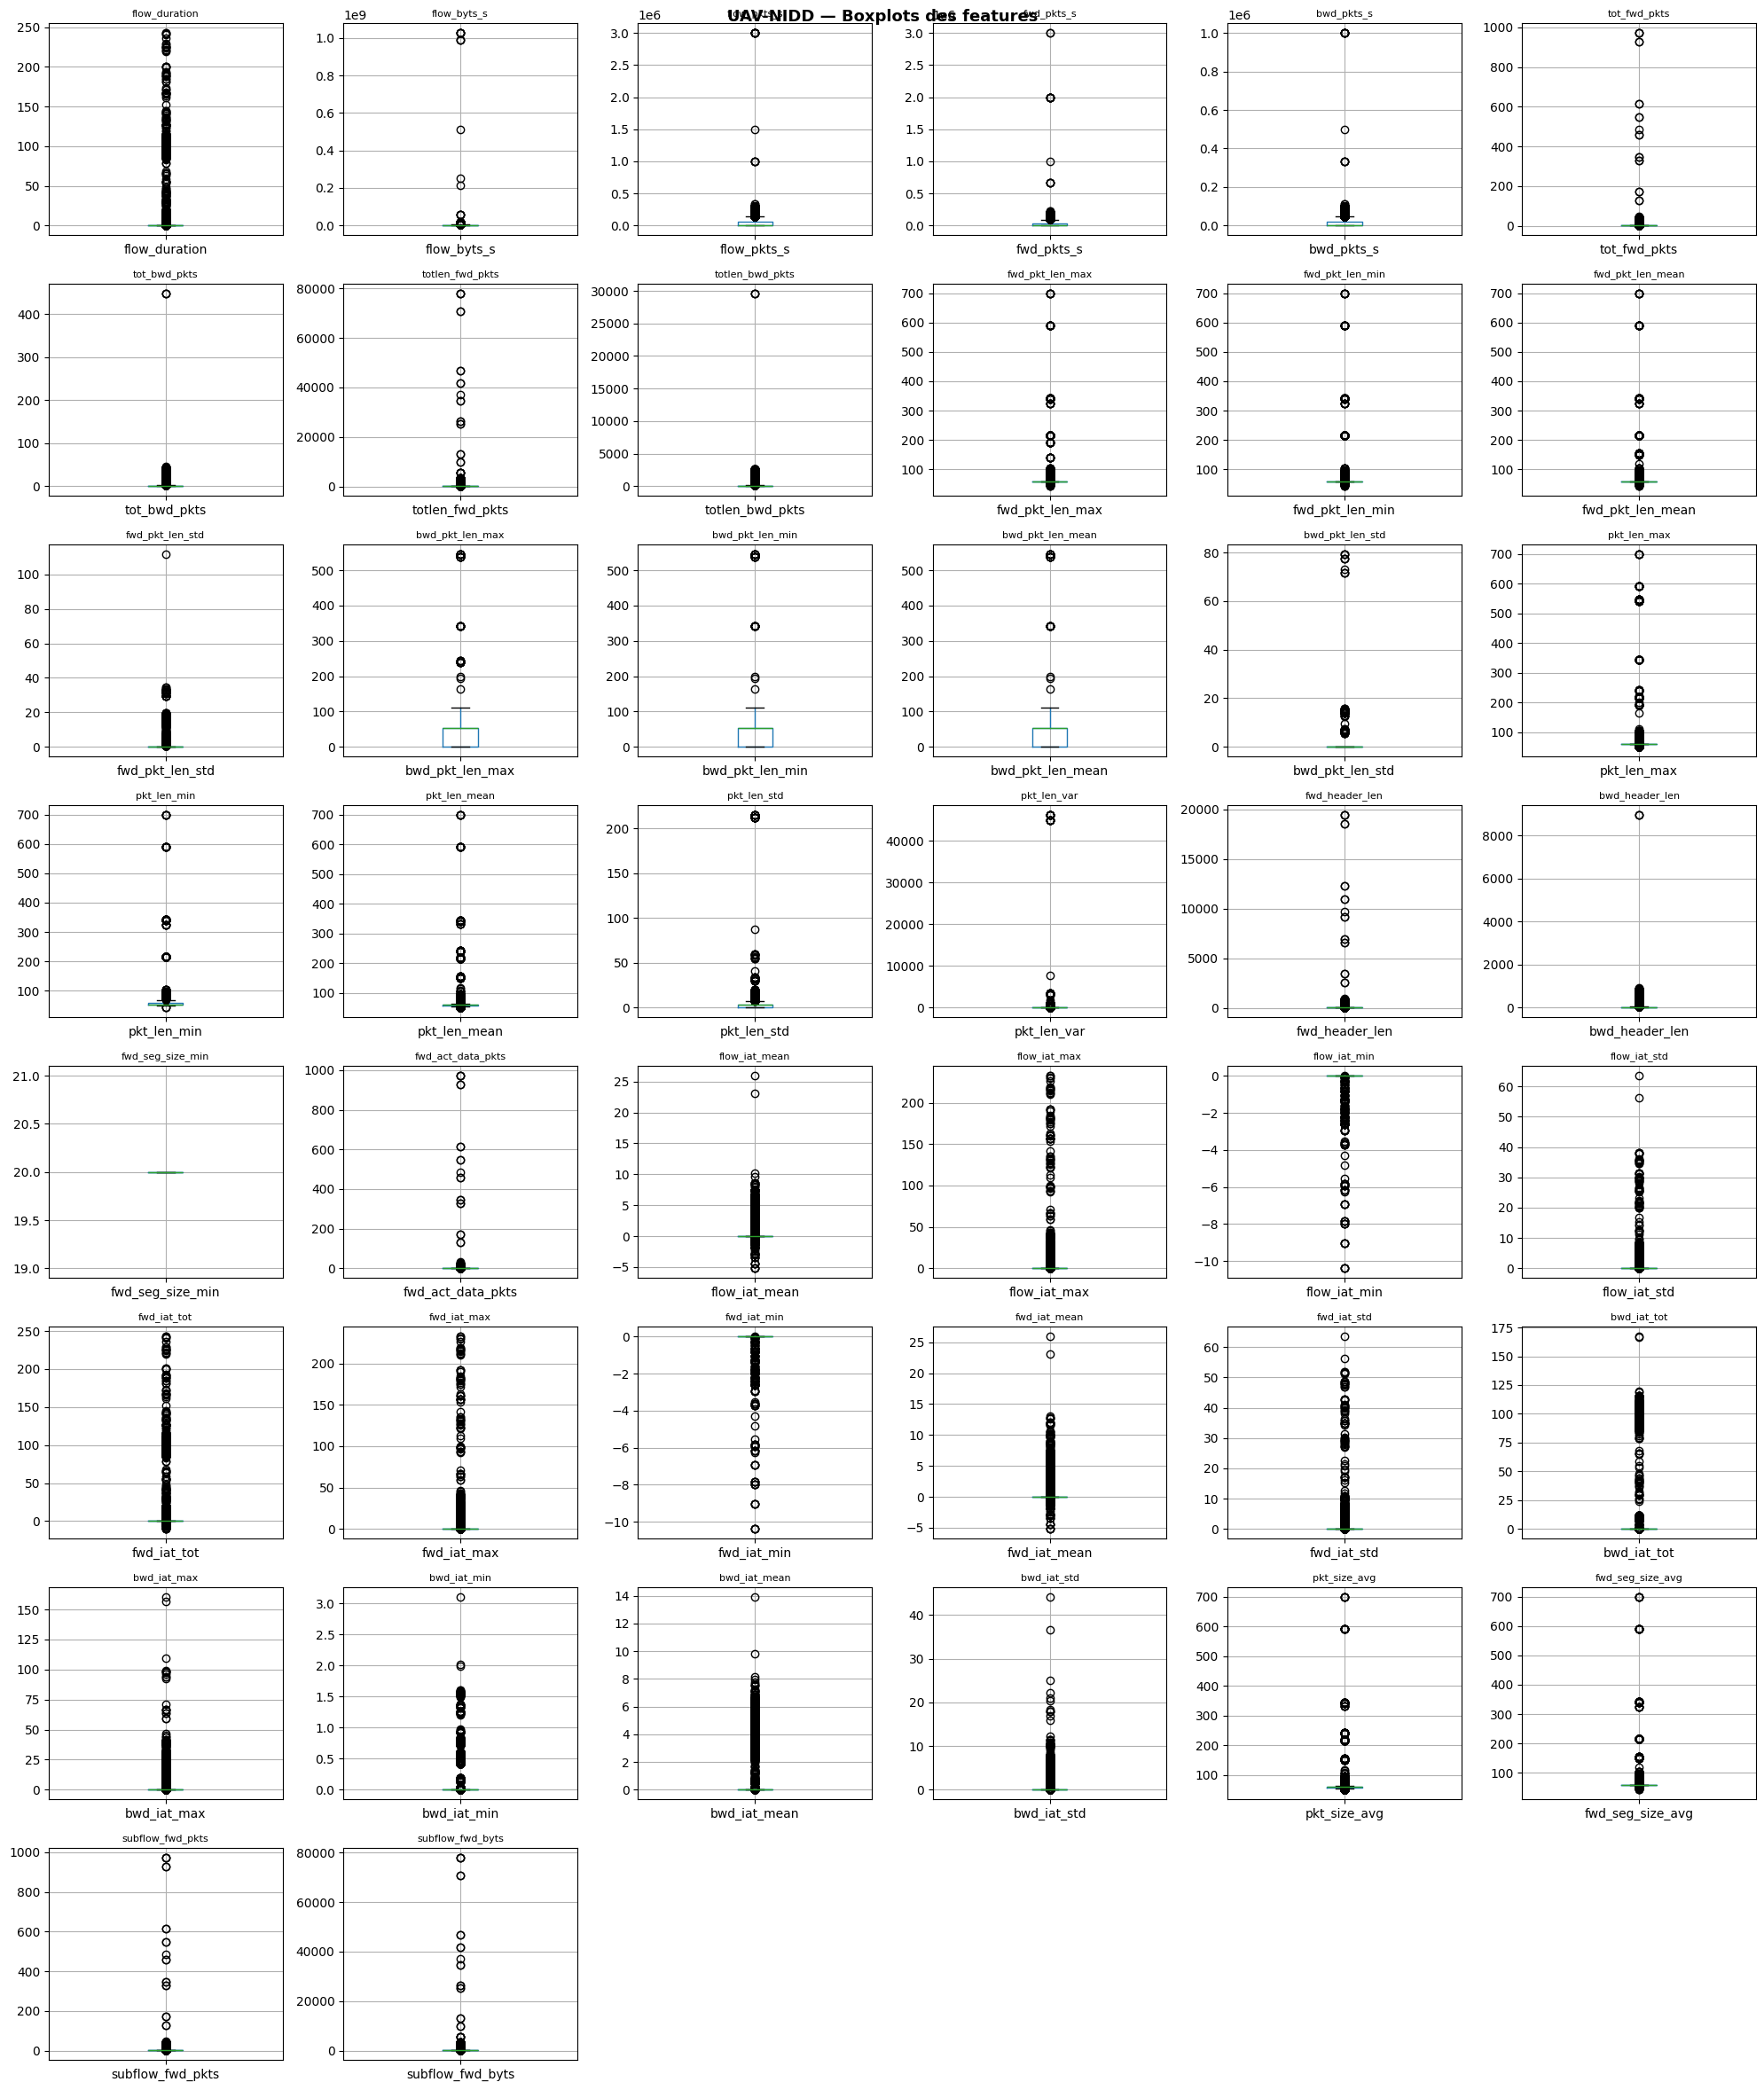

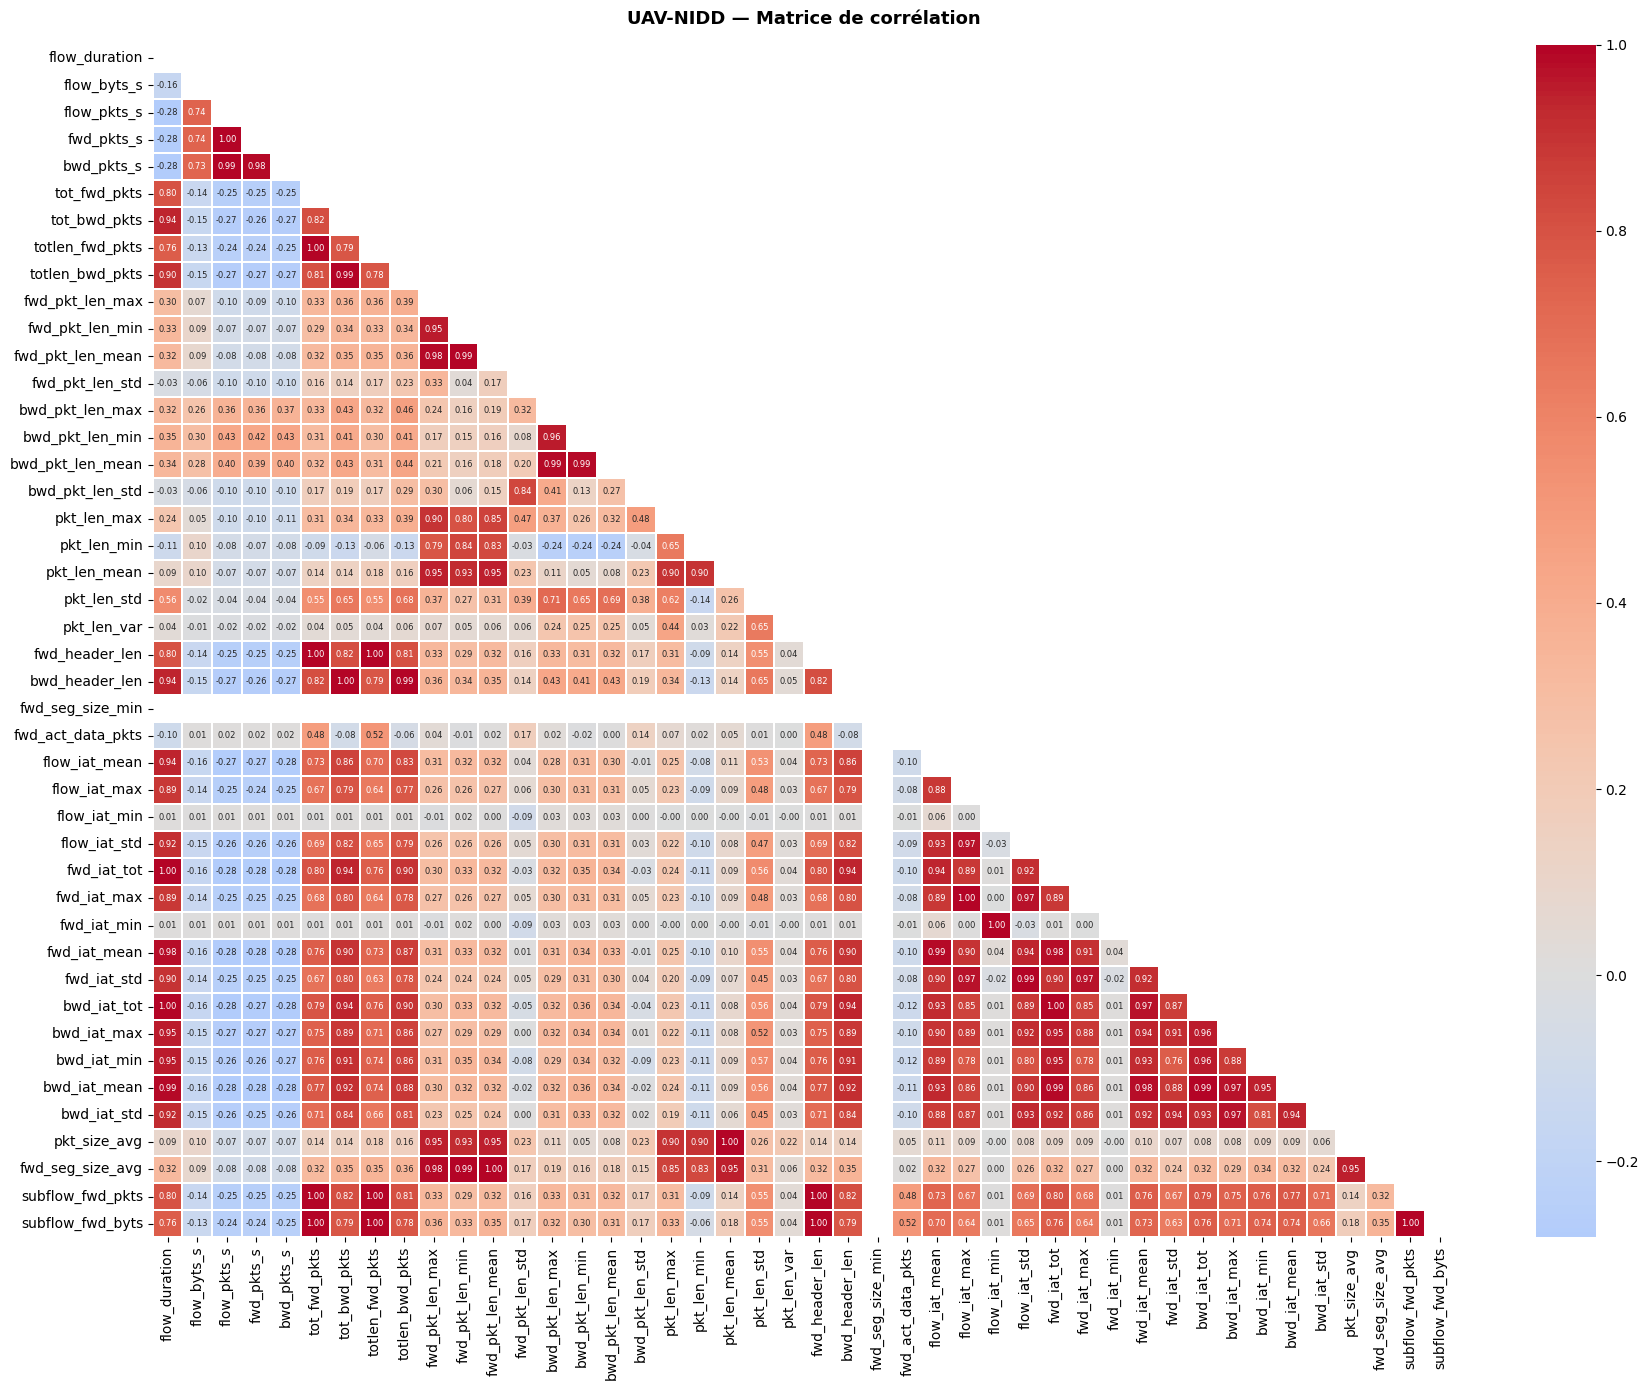

C:\Users\skhabaz\AppData\Local\Temp\ipykernel_14760\2838931735.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_14760\2838931735.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_14760\2838931735.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=col,
C:\Users\skhabaz\AppData\Local\Temp\ipykernel_14760\2838931735.py:179: FutureWarning: 

Passing `palette` 

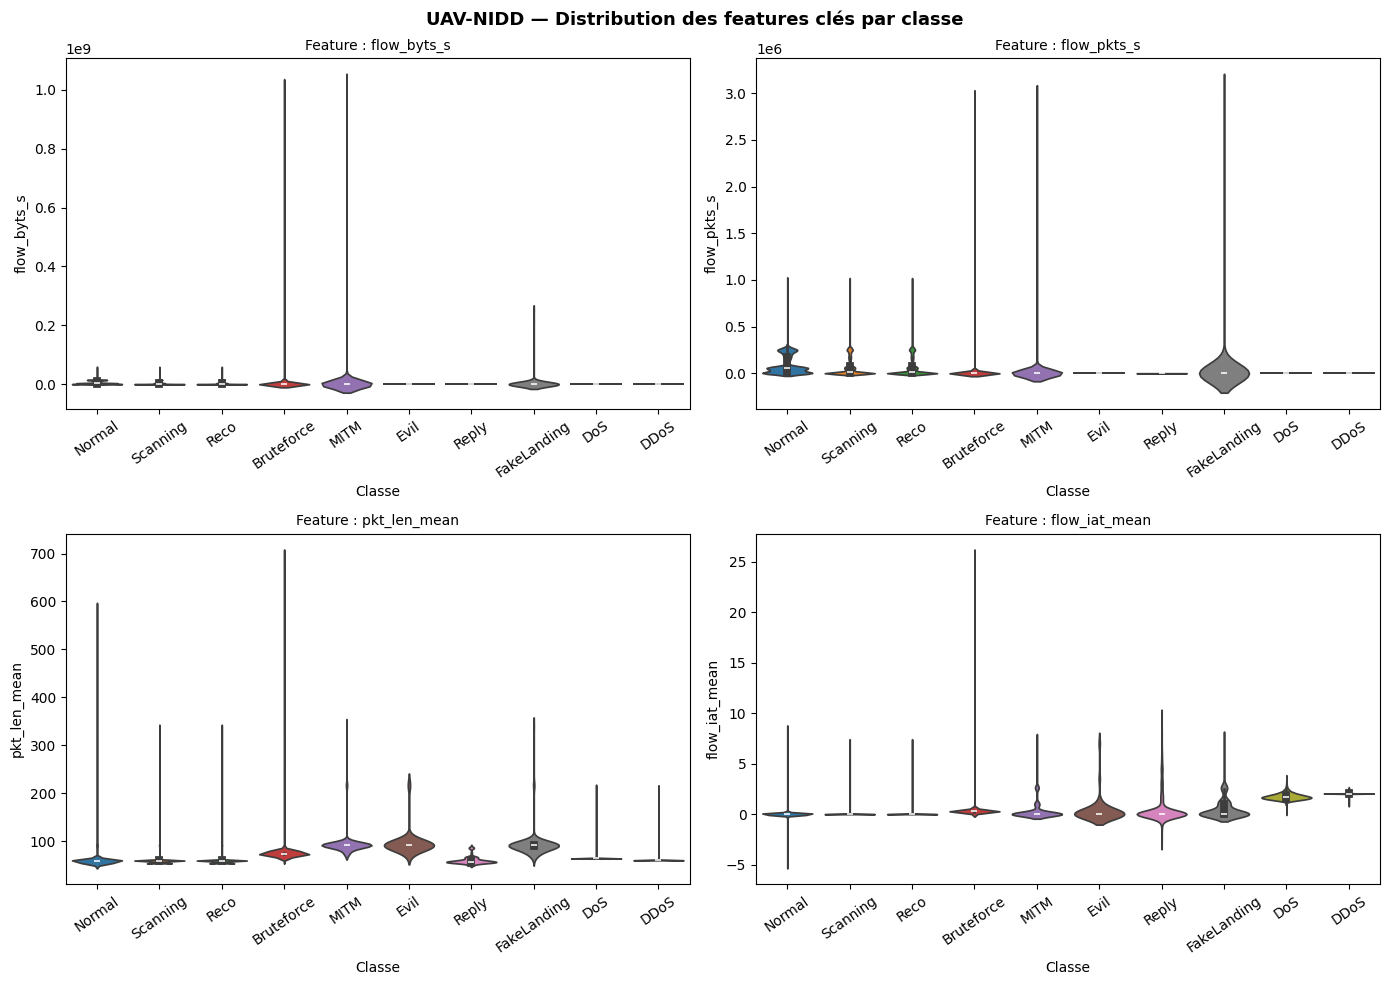

In [ ]:
# ============================================================
# NOTEBOOK : Exploration des données — UAV-NIDD
# Dataset  : UAV Network Intrusion Detection Dataset
# ============================================================

# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DU DATASET
# ────────────────────────────────────────
UAV = r"C:\Drone_Attack_Similarity_Project\DATASET\UAV_NIDD\Normal\Normal.csv"
df = pd.read_csv(UAV)
print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
# ────────────────────────────────────────
# 3. DISTRIBUTION DES CLASSES
# ────────────────────────────────────────
class_counts = df['label'].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)

class_df = pd.DataFrame({
    'Nombre de flows' : class_counts,
    'Pourcentage (%)'  : class_pct
})
print(" Distribution des classes :\n")
print(class_df)
print(f"\nTotal : {len(df):,} flows — {df['label'].nunique()} classes")

# Visualisation distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("UAV-NIDD — Distribution des classes",
             fontsize=14, fontweight='bold')

colors = sns.color_palette("tab10", n_colors=df['label'].nunique())

# Barplot
class_counts.plot(kind='bar', ax=axes[0], color=colors,
                  edgecolor='black', width=0.6)
axes[0].set_title("Nombre de flows par classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de flows")
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(class_counts.values,
            labels=class_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("UAVNIDD_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 4. ANALYSE DES VALEURS MANQUANTES
# ────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing,
    'Pourcentage (%)'    : missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print(" Valeurs manquantes :\n")
if missing_df['Valeurs manquantes'].sum() > 0:
    print(missing_df[missing_df['Valeurs manquantes'] > 0])

    plt.figure(figsize=(12, 4))
    missing_df[missing_df['Valeurs manquantes'] > 0]['Pourcentage (%)'].plot(
        kind='bar', color='#E91E63', edgecolor='black')
    plt.title("Pourcentage de valeurs manquantes par feature")
    plt.ylabel("% valeurs manquantes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("UAVNIDD_missing_values.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(" Aucune valeur manquante détectée")

# ────────────────────────────────────────
# 5. DISTRIBUTION DES FEATURES NUMÉRIQUES
# ────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f" {len(num_cols)} features numériques : {num_cols}")

# Histogrammes
n_cols_plot = 6
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(20, n_rows_plot * 3))
fig.suptitle("UAV-NIDD — Distribution des features (histogrammes)",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols):
    axes_flat[i].hist(df[col].dropna(), bins=40,
                      color='#4CAF50', edgecolor='white', alpha=0.8)
    axes_flat[i].set_title(col, fontsize=8)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("UAVNIDD_histogrammes.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 6. BOXPLOTS — DÉTECTION DES OUTLIERS
# ────────────────────────────────────────
fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                          figsize=(20, n_rows_plot * 3))
fig.suptitle("UAV-NIDD — Boxplots des features",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes_flat[i])
    axes_flat[i].set_title(col, fontsize=8)
    axes_flat[i].set_xlabel("")

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("UAVNIDD_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 7. MATRICE DE CORRÉLATION
# ────────────────────────────────────────
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            annot_kws={"size": 6})
plt.title("UAV-NIDD — Matrice de corrélation",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("UAVNIDD_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 8. FEATURES PAR CLASSE (violin plots)
# ────────────────────────────────────────
top_features = ['flow_byts_s', 'flow_pkts_s', 'pkt_len_mean', 'flow_iat_mean']
top_features = [f for f in top_features if f in df.columns]

if top_features:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("UAV-NIDD — Distribution des features clés par classe",
                 fontsize=13, fontweight='bold')
    axes_flat = axes.flatten()

    for i, col in enumerate(top_features):
        sns.violinplot(data=df, x='label', y=col,
                       ax=axes_flat[i],
                       palette=sns.color_palette("tab10",
                               n_colors=df['label'].nunique()))
        axes_flat[i].set_title(f"Feature : {col}", fontsize=10)
        axes_flat[i].set_xlabel("Classe")
        axes_flat[i].tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.savefig("UAVNIDD_violin_plots.png", dpi=150, bbox_inches='tight')
    plt.show()